In [27]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import pathlib
from datetime import datetime

#install xarray
%pip install xarray
import xarray as xr

Note: you may need to restart the kernel to use updated packages.


In [28]:
Stock_TC = pd.read_excel('Stock_TC.xlsx')
Type_split = pd.read_excel('final_type_split.xlsx')

In [29]:
'''Reindexing to get right shape (Renamed to Type_split_ because of ipynb-issues)'''

#print(Type_split.sum(axis=1))

#Set year as index type split
Type_split_ = Type_split.set_index('Year')

#print(Type_split_.head())

'''Convert to numpy array'''

Type_split_array = Type_split_.to_numpy()
Type_split_array

array([[0.        , 0.        , 0.        , 1.        ],
       [0.        , 0.        , 0.        , 1.        ],
       [0.        , 0.        , 0.        , 1.        ],
       ...,
       [0.17313351, 0.26421469, 0.55415056, 0.00857414],
       [0.17313351, 0.26421469, 0.55415056, 0.00857414],
       [0.17313351, 0.26421469, 0.55415056, 0.00857414]], shape=(501, 4))


# Redo multiplication
Stock_TCJ = Stock_TC.values[:, :, np.newaxis] * Type_split_.values[:, np.newaxis, :]

# Rebuild xarray with labels
Stock_TCJ = xr.DataArray(
    Stock_TCJ,
    dims=["time", "cohort", "type"],
    coords={
        "time":   Stock_TC.index,
        "cohort": Stock_TC.columns,
        "type":   Type_split_.columns,
    }
)




Stock_T = Stock_TCJ.sum(dim=["cohort", "type"]).to_pandas()
Stock_TC_check = Stock_TC.sum(axis=1)

plt.plot(Stock_T, label="From Stock_TCJ", linewidth=0.8)
plt.plot(Stock_TC_check, label="Original Stock_TC", linewidth=0.8, linestyle="--")
plt.legend()
plt.title("Mass conservation check")
plt.grid(False)
plt.show()

In [ ]:
'''Stock_TC_ is Stock_TC with year as index, changed name for ipynb trouble'''
Stock_TC_ = Stock_TC.set_index('year')
Stock_TC_

Stock_TC_array = Stock_TC_.to_numpy()

In [ ]:
Stock_TCJ_np = np.einsum('tc,cj->tcj', Stock_TC_array, Type_split_array)

Stock_TCJ_np.shape

(501, 501, 4)

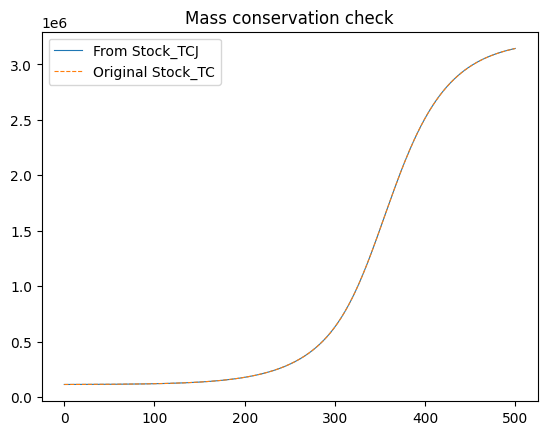

In [ ]:
# Sum over cohort and type dimensions, should match original Stock_TC summed over cohorts
Stock_TCJ_sum = Stock_TCJ_np.sum(axis=(1, 2))  # sum over C and J
Stock_TC_sum = Stock_TC_.sum(axis=1)          # sum over C


plt.plot(Stock_TCJ_sum, label="From Stock_TCJ", linewidth=0.8)
plt.plot(Stock_TC_sum.values, label="Original Stock_TC", linewidth=0.8, linestyle="--")
plt.legend()
plt.title("Mass conservation check")
plt.grid(False)
plt.show()

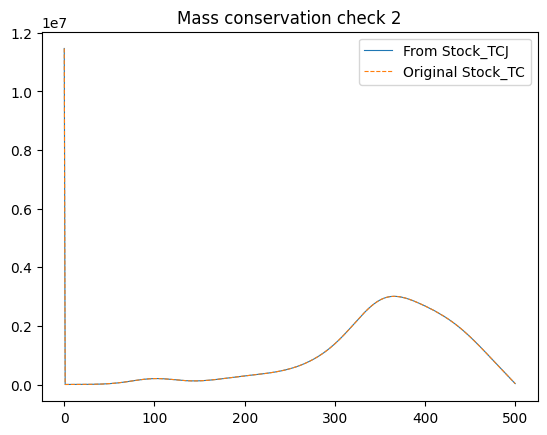

In [40]:
# Sum over cohort and type dimensions, should match original Stock_TC summed over cohorts
Stock_TCJ_sum = Stock_TCJ_np.sum(axis=(0, 2))  # sum over C and J
Stock_TC_sum = Stock_TC_.sum(axis=0)          # sum over C


plt.plot(Stock_TCJ_sum, label="From Stock_TCJ", linewidth=0.8)
plt.plot(Stock_TC_sum.values, label="Original Stock_TC", linewidth=0.8, linestyle="--")
plt.legend()
plt.title("Mass conservation check 2")
plt.grid(False)
plt.show()

# Save Stock_TCJ with full xarray metadata (dims + coords)
stock_to_save = Stock_TCJ.copy()

# netCDF requires homogeneous coord dtypes; store cohort labels as strings
stock_to_save = stock_to_save.assign_coords(
    cohort=stock_to_save.coords["cohort"].values.astype(str)
),
stock_to_save.name = "Stock_TCJ"
stock_to_save.to_netcdf("Stock_TCJ.nc")

print("Saved: Stock_TCJ.nc")
print("dims:", stock_to_save.dims)